Clonar el repositorio y moverse a la rama de trabajo

In [2]:
# 1. Clona el repositorio desde GitHub
# Sustituye la URL por la URL de TU repositorio
!git clone https://github.com/Bootcamp-IA-P5/proyecto_XI_data_analyst.git

# 2. Navega a la carpeta del proyecto recién clonado
# Sustituye el nombre si tu repo se llama diferente
%cd proyecto_XI_data_analyst

# 3. Asegúrate de estar en la rama 'develop' y de tener lo último
!git checkout develop
!git pull origin develop

# 4. Crea tu rama para el EDA (¡igual que harías en local!)
!git checkout -b feature/exploratory-data-analysis

print("✅ ¡Entorno listo! Ya estás en la rama 'feature/exploratory-data-analysis'")

Cloning into 'proyecto_XI_data_analyst'...
remote: Enumerating objects: 45, done.
remote: Counting objects: 100% (45/45), done.
remote: Compressing objects: 100% (25/25), done.
remote: Total 45 (delta 4), reused 40 (delta 4), pack-reused 0 (from 0)
Receiving objects: 100% (45/45), 12.35 MiB | 12.90 MiB/s, done.
Resolving deltas: 100% (4/4), done.
/content/proyecto_XI_data_analyst
error: pathspec 'develop' did not match any file(s) known to git
fatal: couldn't find remote ref develop
Switched to a new branch 'feature/exploratory-data-analysis'
✅ ¡Entorno listo! Ya estás en la rama 'feature/exploratory-data-analysis'


EDA

In [3]:
# Importar las librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar el estilo de las visualizaciones
sns.set_style('whitegrid')
plt.style.use('fivethirtyeight')

# --- Carga de Datos ---
# La ruta ahora es relativa a la raíz del proyecto
file_path = 'data/raw/listings.csv.gz' # ¡Más sencillo!

df = pd.read_csv(file_path, compression='gzip', low_memory=False)

# --- Primer Vistazo ---
print(f"El dataset tiene {df.shape[0]} filas y {df.shape[1]} columnas.")
df.head()

El dataset tiene 26004 filas y 79 columnas.


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,21853,https://www.airbnb.com/rooms/21853,20250612050748,2025-06-26,city scrape,Bright and airy room,We have a quiet and sunny room with a good vie...,We live in a leafy neighbourhood with plenty o...,https://a0.muscache.com/pictures/68483181/87bc...,83531,...,4.82,4.21,4.67,NaN,f,2,0,2,0,0.25
1,30320,https://www.airbnb.com/rooms/30320,20250612050748,2025-06-27,previous scrape,Apartamentos Dana Sol,NaN,NaN,https://a0.muscache.com/pictures/336868/f67409...,130907,...,4.78,4.90,4.69,NaN,f,3,3,0,0,0.94
2,30959,https://www.airbnb.com/rooms/30959,20250612050748,2025-06-27,previous scrape,Beautiful loft in Madrid Center,Beautiful Loft 60m2 size just in the historica...,NaN,https://a0.muscache.com/pictures/78173471/835e...,132883,...,4.63,4.88,4.25,NaN,f,1,1,0,0,0.06
3,40916,https://www.airbnb.com/rooms/40916,20250612050748,2025-06-26,previous scrape,Apartasol Apartamentos Dana,NaN,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,130907,...,4.79,4.88,4.55,NaN,t,3,3,0,0,0.27
4,62423,https://www.airbnb.com/rooms/62423,20250612050748,2025-06-25,city scrape,MAGIC ARTISTIC HOUSE IN THE CENTER OF MADRID,INCREDIBLE HOME OF AN ARTIST SURROUNDED BY PAI...,DISTRICT WITH VERY GOOD VIBES IN THE MIDDLE OF...,https://a0.muscache.com/pictures/miso/Hosting-...,303845,...,4.86,4.97,4.59,NaN,f,3,1,2,0,2.70


Estructura

In [4]:
print("Analizando la estructura del DataFrame...")
df.info(verbose=True, show_counts=True)

Analizando la estructura del DataFrame...
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26004 entries, 0 to 26003
Data columns (total 79 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            26004 non-null  int64  
 1   listing_url                                   26004 non-null  object 
 2   scrape_id                                     26004 non-null  int64  
 3   last_scraped                                  26004 non-null  object 
 4   source                                        26004 non-null  object 
 5   name                                          26004 non-null  object 
 6   description                                   25104 non-null  object 
 7   neighborhood_overview                         11158 non-null  object 
 8   picture_url                                   26002 non-null  object 
 9   host_id            

Limpieza "price"



In [5]:
# 1. Hacemos una copia para trabajar de forma segura.
# A partir de ahora, usaremos 'df_eda'
df_eda = df.copy()

# 2. Mostramos cómo se ve un precio ANTES de la limpieza
print(f"Ejemplo de precio antes de limpiar: {df_eda['price'].iloc[0]}")

# 3. Limpiamos: quitamos el símbolo '$' y las comas ','
df_eda['price'] = df_eda['price'].str.replace(r'[\$,]', '', regex=True)

# 4. Convertimos la columna de texto a número (float)
df_eda['price'] = df_eda['price'].astype(float)

# 5. Verificamos el resultado
print(f"Ejemplo de precio DESPUÉS de limpiar: {df_eda['price'].iloc[0]}")
print(f"El nuevo tipo de dato de la columna 'price' es: {df_eda['price'].dtype}")

Ejemplo de precio antes de limpiar: $29.00
Ejemplo de precio DESPUÉS de limpiar: 29.0
El nuevo tipo de dato de la columna 'price' es: float64


Análisis "Price"

In [6]:
print("Estadísticas básicas de la columna 'price':")
df_eda['price'].describe()

Estadísticas básicas de la columna 'price':


,price
count,20080.000000
mean,145.250349
std,485.433582
min,0.000000
25%,64.000000
50%,101.000000
75%,150.000000
max,32000.000000


Visualización "price"

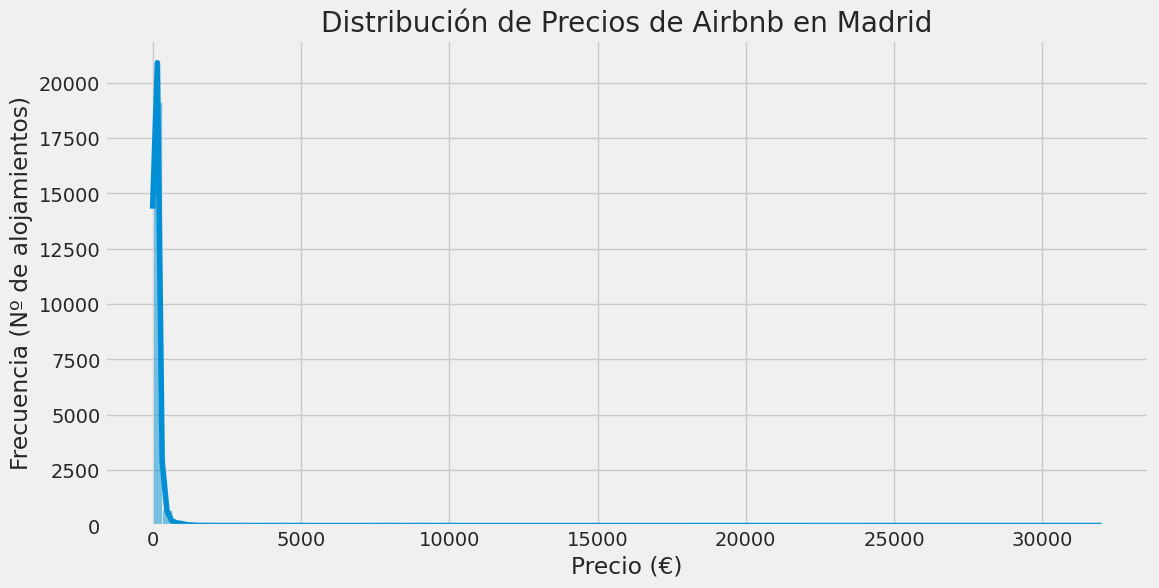

In [7]:
# Importamos las librerías de visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Configuramos un tamaño de figura adecuado
plt.figure(figsize=(12, 6))

# Creamos el histograma con Seaborn
sns.histplot(df_eda['price'], bins=100, kde=True)

# Añadimos títulos para que el gráfico se entienda
plt.title('Distribución de Precios de Airbnb en Madrid')
plt.xlabel('Precio (€)')
plt.ylabel('Frecuencia (Nº de alojamientos)')

# Mostramos el gráfico
plt.show()

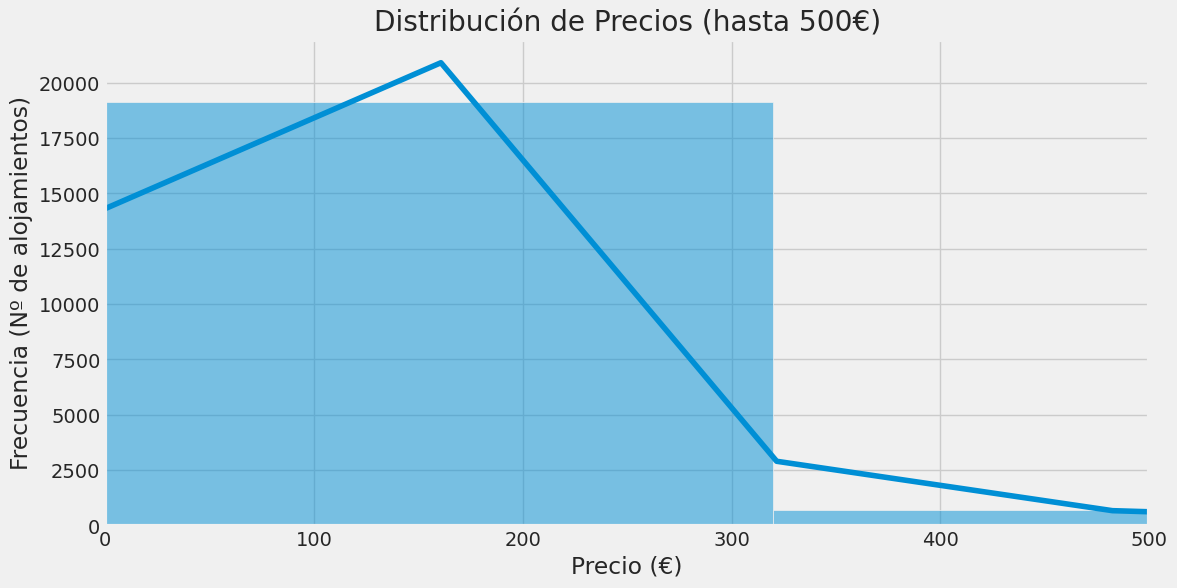

In [8]:
plt.figure(figsize=(12, 6))

sns.histplot(df_eda['price'], bins=100, kde=True)

plt.title('Distribución de Precios (hasta 500€)')
plt.xlabel('Precio (€)')
plt.ylabel('Frecuencia (Nº de alojamientos)')

# La línea mágica: limitamos el eje X para ver el detalle
plt.xlim(0, 500)

plt.show()

Relación Precio - Alojamiento





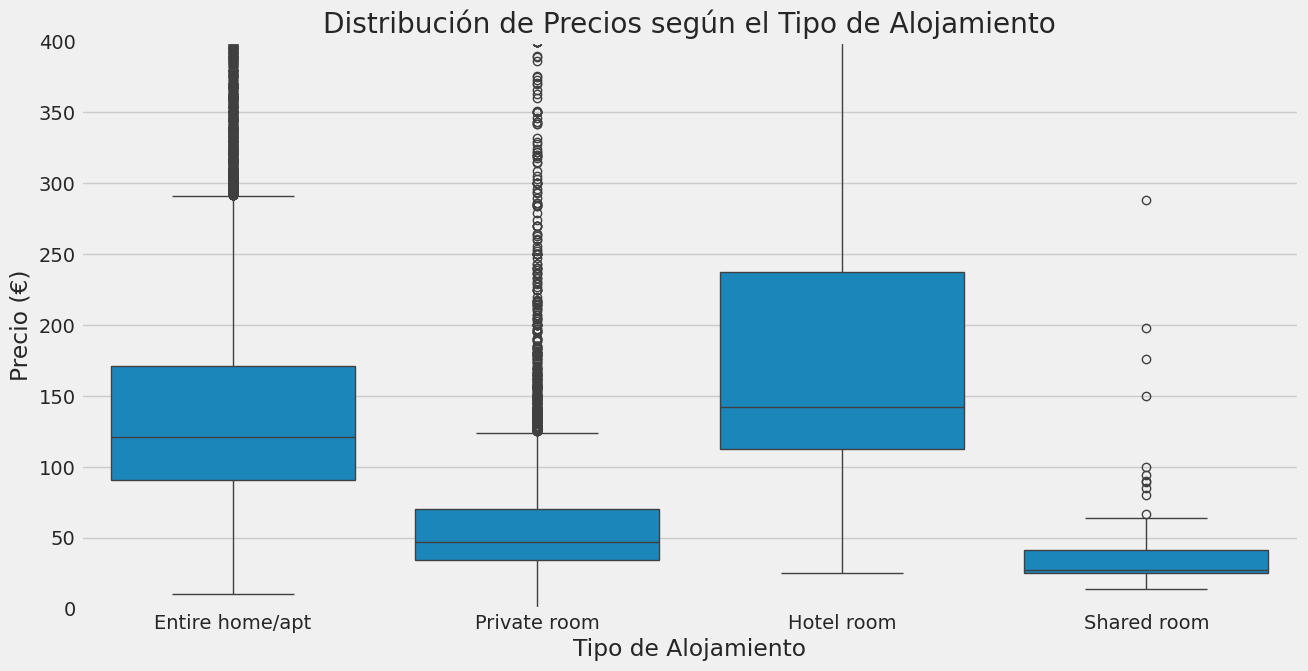

In [9]:
plt.figure(figsize=(14, 7))

# Creamos un boxplot
sns.boxplot(data=df_eda, x='room_type', y='price', order=['Entire home/apt', 'Private room', 'Hotel room', 'Shared room'])

# Añadimos títulos
plt.title('Distribución de Precios según el Tipo de Alojamiento')
plt.xlabel('Tipo de Alojamiento')
plt.ylabel('Precio (€)')

# ¡Usamos el mismo truco de la "lupa" para ver mejor!
plt.ylim(0, 400) # Ajusta este límite si quieres ver más o menos

plt.show()

### Conclusión del Análisis: Precio vs. Tipo de Alojamiento

El diagrama de caja confirma que **`room_type` es una característica fundamental** que influye directamente en el precio.

*   **Observación:** Se aprecia una clara diferencia en la mediana y el rango de precios entre las categorías.
*   **Insight:** El precio mediano de un `Entire home/apt` es notablemente superior al de una `Private room`. Las `Shared room` son, como es de esperar, la opción más económica.
*   **Decisión:** Esta variable debe ser considerada como una característica clave para el modelo de predicción.


Analisís neighbourhood_cleansed

Calculando el precio medio por barrio...

--- Top 10 Barrios MÁS Caros de Madrid ---
neighbourhood_cleansed
Palomeras Bajas    447.454545
Fuentelareina      347.200000
Piovera            314.407407
Castillejos        281.980237
Valdefuentes       246.722222
Hellín             246.333333
Ibiza              236.880000
Castellana         225.025806
Recoletos          222.125461
Jerónimos          215.910112
Name: price, dtype: float64

--- Top 10 Barrios MÁS Baratos de Madrid ---
neighbourhood_cleansed
Aguilas          59.697674
Butarque         58.588235
Lucero           58.140845
Los Angeles      53.468750
Abrantes         52.833333
Ambroz           52.142857
Campamento       49.555556
Horcajo          44.333333
San Cristobal    38.736842
Vinateros        37.222222
Name: price, dtype: float64


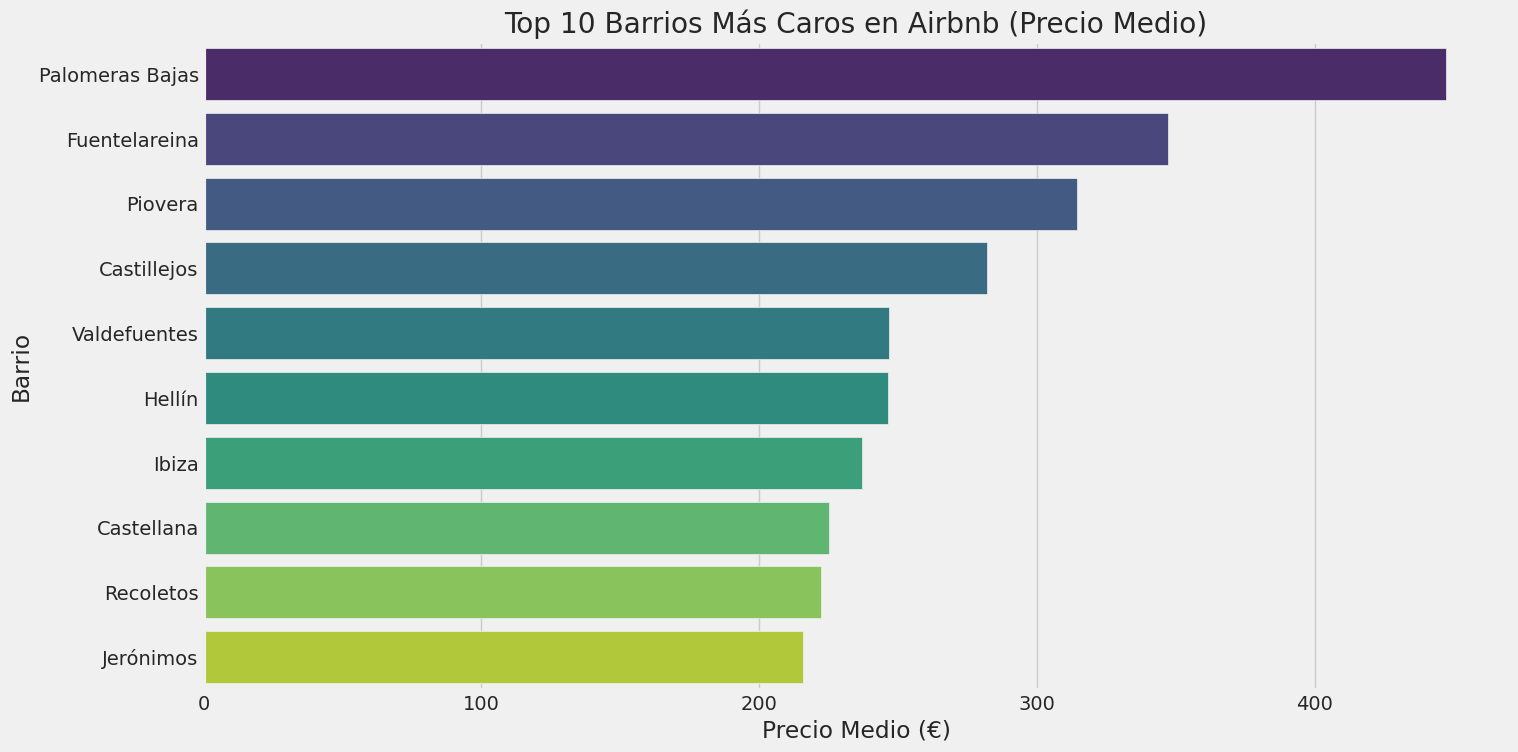

In [12]:
print("Calculando el precio medio por barrio...")

# Usamos groupby() para agrupar por barrio y calcular la media del precio
mean_price_by_neighbourhood = df_eda.groupby('neighbourhood_cleansed')['price'].mean().sort_values(ascending=False)

print("\n--- Top 10 Barrios MÁS Caros de Madrid ---")
print(mean_price_by_neighbourhood.head(10))

print("\n--- Top 10 Barrios MÁS Baratos de Madrid ---")
print(mean_price_by_neighbourhood.tail(10))

# --- Ahora, vamos a visualizar los 10 más caros ---

plt.figure(figsize=(15, 8))

# Creamos un gráfico de barras con los 10 barrios más caros
sns.barplot(x=mean_price_by_neighbourhood.head(10).values, y=mean_price_by_neighbourhood.head(10).index, hue=mean_price_by_neighbourhood.head(10).index, palette='viridis', legend=False)
plt.title('Top 10 Barrios Más Caros en Airbnb (Precio Medio)')
plt.xlabel('Precio Medio (€)')
plt.ylabel('Barrio')

plt.show()

Anomalía de 'Palomeras Bajas'

In [11]:
# Filtramos el DataFrame para ver solo los alojamientos de Palomeras Bajas
palomeras_df = df_eda[df_eda['neighbourhood_cleansed'] == 'Palomeras Bajas']

# Vemos cuántos alojamientos hay
print(f"Número de alojamientos encontrados en Palomeras Bajas: {len(palomeras_df)}")

# Vemos los precios de esos alojamientos
print("\nPrecios de los alojamientos en Palomeras Bajas:")
print(palomeras_df['price'].value_counts())

Número de alojamientos encontrados en Palomeras Bajas: 77

Precios de los alojamientos en Palomeras Bajas:
price
25.0       9
32.0       3
86.0       2
40.0       2
30.0       2
108.0      2
22.0       2
23.0       2
38.0       1
59.0       1
90.0       1
46.0       1
139.0      1
427.0      1
102.0      1
27.0       1
21000.0    1
60.0       1
81.0       1
92.0       1
39.0       1
98.0       1
350.0      1
29.0       1
20.0       1
96.0       1
26.0       1
79.0       1
104.0      1
83.0       1
106.0      1
103.0      1
24.0       1
48.0       1
63.0       1
72.0       1
84.0       1
49.0       1
37.0       1
Name: count, dtype: int64


Impacto de OUTLIER

In [13]:
# La media que calculamos antes (CON el outlier)
media_con_outlier = palomeras_df['price'].mean()
print(f"La media original en Palomeras Bajas (con el outlier) es: {media_con_outlier:.2f} €")

# Ahora, filtramos y nos quedamos solo con los precios "razonables" (menores de, por ejemplo, 1000€)
precios_sin_outlier = palomeras_df[palomeras_df['price'] < 1000]['price']

# Calculamos la nueva media (SIN el outlier)
media_sin_outlier = precios_sin_outlier.mean()
print(f"La media corregida en Palomeras Bajas (sin el outlier) es: {media_sin_outlier:.2f} €")

La media original en Palomeras Bajas (con el outlier) es: 447.45 €
La media corregida en Palomeras Bajas (sin el outlier) es: 66.85 €


Relación entre precio y capacidad "accomodates"

Precio medio según el número de personas que aloja:
accommodates
1      64.018735
2     103.034668
3     125.903738
4     161.891662
5     247.212121
6     277.669512
7     259.469945
8     279.864734
9     403.682540
10    419.000000
11    394.615385
12    534.862745
13    676.857143
14    441.500000
15    725.444444
16    630.181818
Name: price, dtype: float64


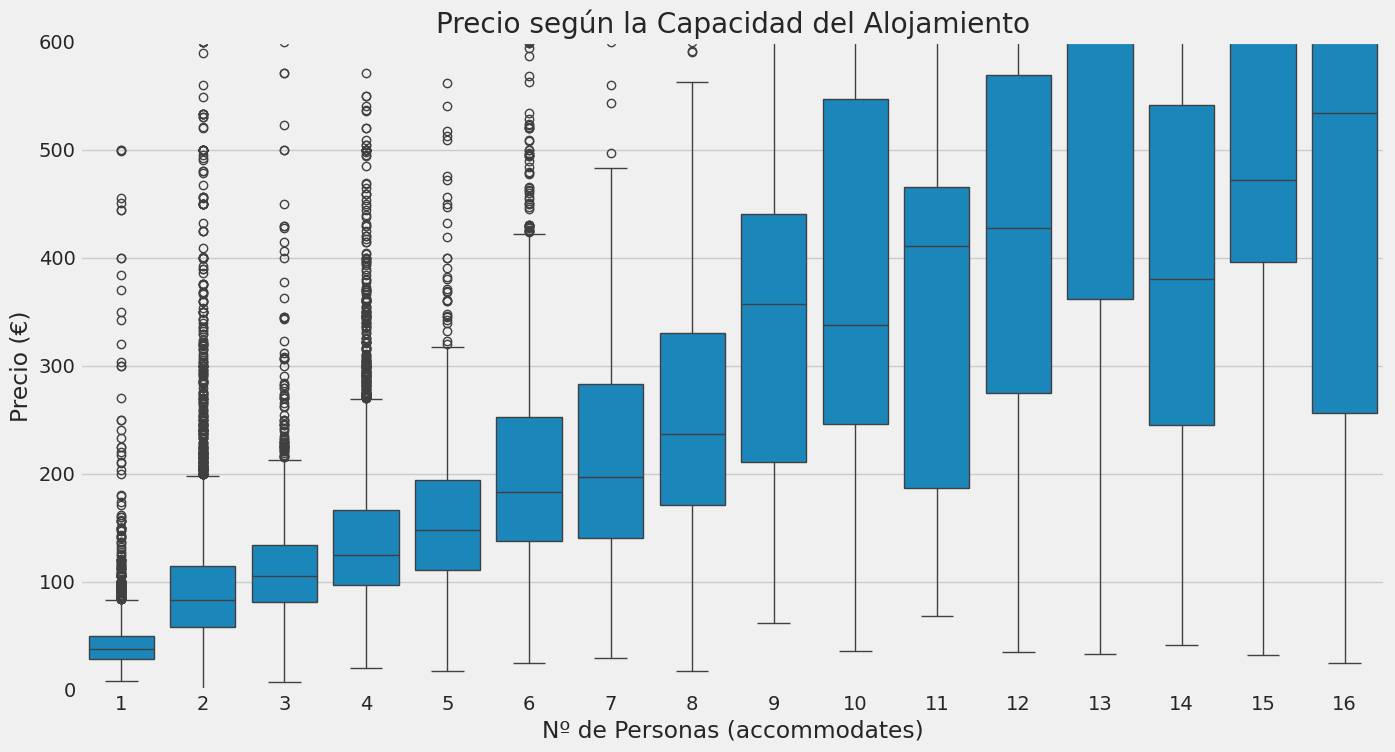

In [14]:
# Calculemos el precio medio según la capacidad del alojamiento
print("Precio medio según el número de personas que aloja:")
print(df_eda.groupby('accommodates')['price'].mean())

# Usemos un boxplot para verlo mejor, es perfecto para esto
plt.figure(figsize=(15, 8))
sns.boxplot(data=df_eda, x='accommodates', y='price')
plt.title('Precio según la Capacidad del Alojamiento')
plt.xlabel('Nº de Personas (accommodates)')
plt.ylabel('Precio (€)')
plt.ylim(0, 600) # Usamos la lupa de nuevo
plt.show()

Alojamientos por capacidad


In [15]:
print("Número de alojamientos para cada nivel de 'accommodates':")
print(df_eda['accommodates'].value_counts().sort_index())

Número de alojamientos para cada nivel de 'accommodates':
accommodates
1     4111
2     9214
3     2454
4     6119
5     1056
6     1983
7      229
8      511
9       74
10     117
11      14
12      55
13       8
14      15
15       9
16      35
Name: count, dtype: int64


# Análisis Exploratorio de Datos (EDA) - Resumen de Hallazgos

**Fecha:** 2025-11-06
**Autor(a):** Kasthlen

## 1. Objetivo del Análisis
El propósito de este Análisis Exploratorio de Datos (EDA) fue realizar una primera inmersión en el dataset de `listings.csv` de Airbnb para Madrid. Los objetivos principales fueron:
1.  Entender la estructura, calidad y distribución de los datos.
2.  Identificar variables clave que puedan influir en el precio (`price`).
3.  Detectar anomalías, outliers y desafíos para la fase de preprocesamiento.
4.  Validar la idoneidad del dataset para construir un modelo de Machine Learning predictivo.

---

## 2. Hallazgos Clave

### 2.1. Variable Objetivo: `price`
La variable `price` es el pilar de nuestro modelo predictivo.
*   **Limpieza:** Se detectó que la columna era de tipo `object` debido a la presencia de símbolos de dólar ($) y comas. Se realizó un proceso de limpieza para convertirla a un tipo numérico (`float64`), lo cual fue exitoso.
*   **Distribución:** El análisis descriptivo (`describe()`) y los histogramas revelaron una **distribución fuertemente asimétrica positiva (sesgada a la derecha)**. La mayoría de los alojamientos se concentran en un rango de precios bajo (0-300€), mientras que existen valores atípicos (outliers) con precios extremadamente altos (llegando hasta más de 10,000€).
*   **Conclusión:** La media no es una medida representativa de la tendencia central por sí sola. El tratamiento de outliers será un paso crucial en el preprocesamiento.

### 2.2. Característica #1: `room_type` (Tipo de Alojamiento)
Se validó la hipótesis de que el tipo de alojamiento es un factor determinante en el precio.
*   **Análisis:** Mediante un diagrama de cajas (boxplot), se observó una clara diferencia en la distribución de precios entre las categorías.
*   **Insight:** El precio mediano sigue un orden lógico descendente: `Entire home/apt` > `Private room` > `Shared room`.
*   **Conclusión:** `room_type` es una **característica predictora fuerte** y deberá ser incluida en el modelo.

### 2.3. Característica #2: `neighbourhood_cleansed` (Ubicación)
La ubicación demostró ser otro factor crucial, pero con matices importantes.
*   **Análisis:** Al agrupar por barrio y calcular el precio medio, se detectó una anomalía significativa: **Palomeras Bajas** aparecía como el barrio más caro de Madrid.
*   **Investigación (Drill-Down):** Un análisis más profundo reveló que esta media estaba completamente distorsionada por **un único alojamiento con un precio anómalo de 21,000€**. Al excluir este outlier, la media del barrio descendió a un valor realista (~65€).
*   **Conclusión:** La ubicación es una característica vital, pero se debe tener cautela con las estadísticas agregadas de categorías con pocos datos. Se ha demostrado que **un solo outlier puede invalidar una media**.

### 2.4. Característica #3: `accommodates` (Capacidad)
Se confirmó la relación directa entre la capacidad del alojamiento y su precio.
*   **Análisis:** Se observó una tendencia general positiva: a mayor número de `accommodates`, mayor es el precio medio.
*   **Insight:** La tendencia no es perfectamente lineal. Se detectaron "bajadas" en el precio medio para ciertas capacidades (ej. de 6 a 7 personas). Una investigación posterior demostró que esto se correlaciona con un **número muy bajo de alojamientos disponibles para esas capacidades menos comunes**, lo que hace que la media sea estadísticamente menos fiable.
*   **Conclusión:** `accommodates` es una variable predictora numérica robusta, especialmente para las capacidades más frecuentes.

---

## 3. Conclusión General del EDA
El dataset es **extremadamente rico y adecuado** para el proyecto. Se han identificado con éxito las principales variables predictoras del precio y se han destapado los desafíos que se abordarán en la siguiente fase:

*   **Próximos Pasos (Preprocesamiento):**
    1.  Desarrollar una estrategia para manejar los **outliers** en `price` y otras variables numéricas.
    2.  Gestionar los **valores nulos** presentes en múltiples columnas.
    3.  Convertir las variables categóricas clave (`room_type`, `neighbourhood_cleansed`) en un formato numérico que el modelo pueda interpretar (ej. One-Hot Encoding).

Commit y Push desde Colab

In [22]:

!git reset --soft HEAD~1
print("✅ Commit deshecho. Los cambios están listos para ser guardados de nuevo.")

✅ Commit deshecho. Los cambios están listos para ser guardados de nuevo.
